# Aruba population trends, 2015-2023


Source file: Table-1.1-Population-population-change-and-population-density.xlsx (Aruba)\
Source: CBS Aruba and the Population Registry Office

---
## 1. Setup

## Imports and paths

This block of code is necessary to create a reproducible notebook environment.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_RAW,
    FIGURES
)

In [2]:
# Verify all paths to ensure stable environment

print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
RAW DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/raw
FIGURES: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/outputs/figures


In [3]:
POPULATION_CHANGE_DENSITY = DATA_RAW / "Table-1.1-Population-population-change-and-population-density.xlsx"

In [4]:
# # Stop early if the source file is missing

if not POPULATION_CHANGE_DENSITY.exists():
    raise FileNotFoundError

## 2. Load and inspect source table

In [5]:
raw_df = pd.read_excel(POPULATION_CHANGE_DENSITY, header=1)

In [6]:
raw_df

,Unnamed: 0,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Total population1,108635.40,108818.30,108651.30,109164.00,109241.20,107932.00,107468.40,107152.30,107566.30
1,- males,51309.20,51461.60,51398.60,51512.00,51515.10,50930.30,50664.30,50440.20,50559.00
2,- females,57326.20,57356.80,57252.70,57652.00,57726.10,57002.00,56804.10,56712.00,57007.30
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Annual rate of population change (%)²,1.35,0.17,-0.15,0.47,0.07,-1.21,-0.43,-0.29,0.39
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Density of population (inhabitants/km²)³,603.50,604.50,603.60,606.50,606.90,599.60,597.00,595.30,597.60
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Males per 1000 females,895.00,897.20,897.70,893.40,892.40,893.40,891.90,889.40,887.00
9,Source: CBS and Population Registry Office,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Inspect the imported table structure

print(raw_df.info())
print(raw_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7 non-null      str    
 1   2015        6 non-null      float64
 2   2016        6 non-null      float64
 3   2017        6 non-null      float64
 4   2018        6 non-null      float64
 5   2019        6 non-null      float64
 6   2020        6 non-null      float64
 7   2021        6 non-null      float64
 8   2022        6 non-null      float64
 9   2023        6 non-null      float64
dtypes: float64(9), str(1)
memory usage: 1.1 KB
None
(10, 10)


## 3. Select indicator rows

In [8]:
main_df = raw_df.rename(columns={"Unnamed: 0":"indicator"}).copy()

wanted_rows = [
    "Total population1",
    " - males", " - females",
    "Annual rate of population change (%)²",
    "Density of population (inhabitants/km²)³",
    "Males per 1000  females"
]

In [9]:
# Keep only the indicator rows needed for analysis

selected_rows_df = main_df.loc[main_df["indicator"].isin(wanted_rows)].copy()

## 4. Reshape the data

In [10]:
# Melt to tidy-format

tidy_df = selected_rows_df.melt(
    id_vars = "indicator",
    var_name = "year",
    value_name = "value"
)

In [11]:
tidy_df.head()

,indicator,year,value
0,Total population1,2015,108635.40
1,- males,2015,51309.20
2,- females,2015,57326.20
3,Annual rate of population change (%)²,2015,1.35
4,Density of population (inhabitants/km²)³,2015,603.50


In [12]:
# Ensure 'year' is stored as integer values

tidy_df["year"] = tidy_df["year"].astype(int)

tidy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   indicator  54 non-null     str    
 1   year       54 non-null     int64  
 2   value      54 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.6 KB


In [13]:
# Pivot back to wide-format and standardize column names

wide_df = tidy_df.pivot(
    index = "year",
    columns = "indicator",
    values = "value").reset_index()

wide_df = wide_df.rename(columns={
    " - females": "population_female",
    " - males": "population_male",
    "Annual rate of population change (%)²": "annual_change_pct",
    "Density of population (inhabitants/km²)³": "density_per_km2",
    "Males per 1000  females": "males_per_1000_females",
    "Total population1": "population_total"
})

In [14]:
# Remove the inherited column-index name from pivot()

wide_df.columns.name = None

## 5. Validate published indicators

In [15]:
# Create new column for male + female population and compare to original population total.

wide_df["male_plus_female"] = wide_df["population_female"] + wide_df["population_male"]

wide_df[["year", "population_total", "male_plus_female"]]

,year,population_total,male_plus_female
0,2015,108635.4,108635.4
1,2016,108818.3,108818.4
2,2017,108651.3,108651.3
3,2018,109164.0,109164.0
4,2019,109241.2,109241.2
5,2020,107932.0,107932.3
6,2021,107468.4,107468.4
7,2022,107152.3,107152.2
8,2023,107566.3,107566.3


In [16]:
# Create new column for males per 1000 females

wide_df["males_per_1000_females_calc"] = (
    wide_df["population_male"].astype(float)
    / wide_df["population_female"].astype(float)
    * 1000
)

wide_df[["year", "males_per_1000_females", "males_per_1000_females_calc"]].round(2)

,year,males_per_1000_females,males_per_1000_females_calc
0,2015,895.0,895.04
1,2016,897.2,897.22
2,2017,897.7,897.75
3,2018,893.4,893.50
4,2019,892.4,892.41
5,2020,893.4,893.48
6,2021,891.9,891.91
7,2022,889.4,889.41
8,2023,887.0,886.89


In [17]:
# Create new column for annual population change in percentages and compare to orig col

wide_df["annual_change_pct_calc"] = wide_df["population_total"].pct_change() * 100

wide_df[["year", "annual_change_pct", "annual_change_pct_calc"]].round(2)

,year,annual_change_pct,annual_change_pct_calc
0,2015,1.35,NaN
1,2016,0.17,0.17
2,2017,-0.15,-0.15
3,2018,0.47,0.47
4,2019,0.07,0.07
5,2020,-1.21,-1.20
6,2021,-0.43,-0.43
7,2022,-0.29,-0.29
8,2023,0.39,0.39


In [18]:
# Create a constant, calculate area/km2 and validate against original Excel values

ARUBA_AREA_KM2 = 180 # constant

wide_df["density_per_km2_calc"] = wide_df["population_total"] / ARUBA_AREA_KM2

wide_df[["year", "density_per_km2", "density_per_km2_calc"]]

,year,density_per_km2,density_per_km2_calc
0,2015,603.5,603.530000
1,2016,604.5,604.546111
2,2017,603.6,603.618333
3,2018,606.5,606.466667
4,2019,606.9,606.895556
5,2020,599.6,599.622222
6,2021,597.0,597.046667
7,2022,595.3,595.290556
8,2023,597.6,597.590556


## 6. Visual analysis

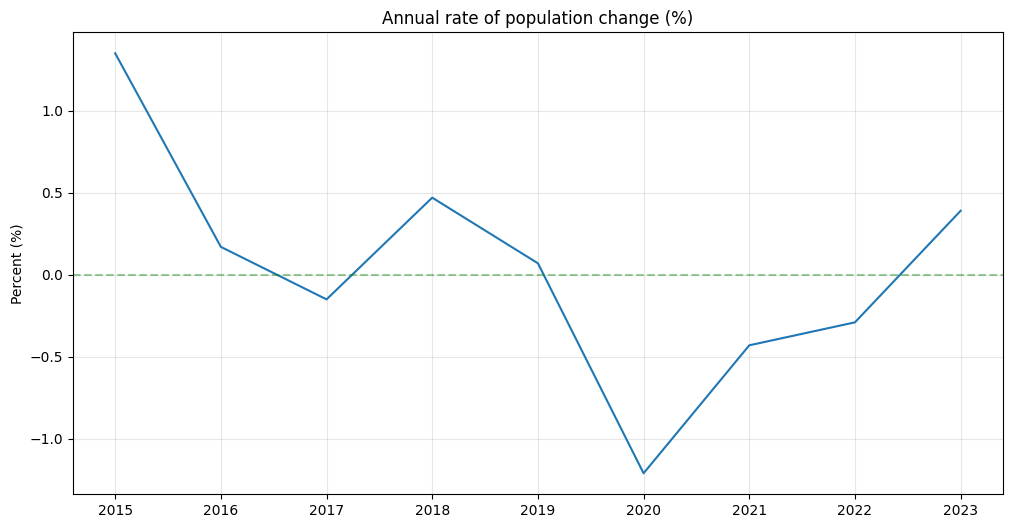

In [19]:
# Annual rate of population change (%)

plt.figure(figsize=(12, 6))

plt.plot(wide_df["year"], wide_df["annual_change_pct"])
plt.axhline(0, linestyle="--", color="green", alpha=0.4)

plt.title("Annual rate of population change (%)")
plt.ylabel("Percent (%)")
plt.grid(alpha=0.3)

plt.savefig(FIGURES / "annual_rate_pop_pct.png", dpi=300, bbox_inches="tight")
plt.show()

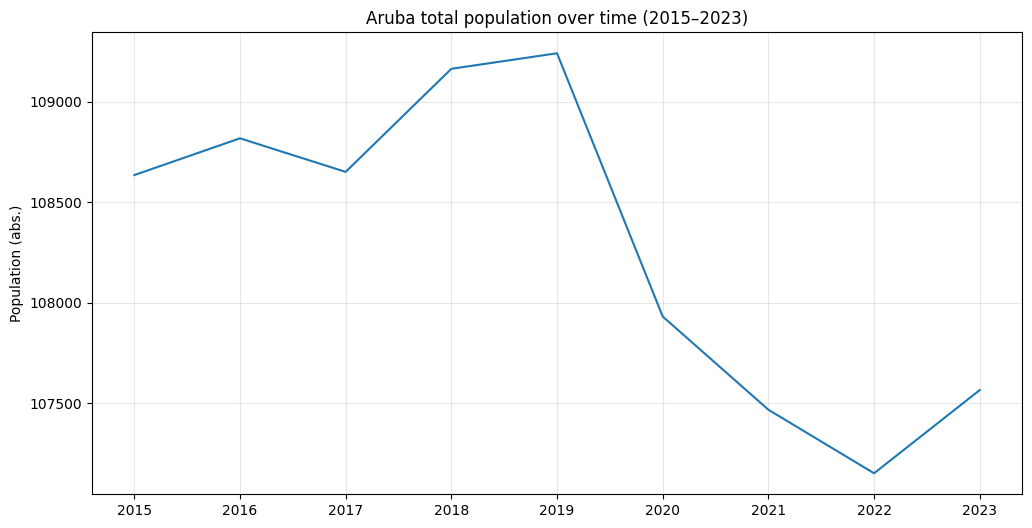

In [20]:
# Total population over time

plt.figure(figsize=(12, 6))

plt.plot(wide_df["year"], wide_df["population_total"])
plt.title("Aruba total population over time (2015–2023)")
plt.ylabel("Population (abs.)")
plt.grid(alpha=0.3)

plt.savefig(FIGURES / "total_population_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

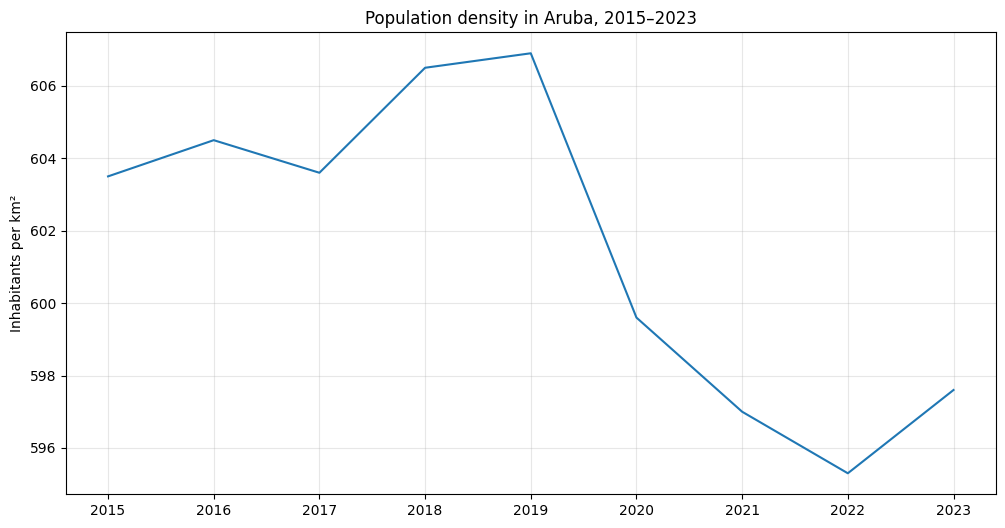

In [21]:
# Density/km2

plt.figure(figsize=(12, 6))

plt.plot(wide_df["year"], wide_df["density_per_km2"])
plt.title("Population density in Aruba, 2015–2023")
plt.ylabel("Inhabitants per km²")
plt.grid(alpha=0.3)

plt.savefig(FIGURES / "population_density_per_kmsq.png", dpi=300, bbox_inches="tight")

plt.show()

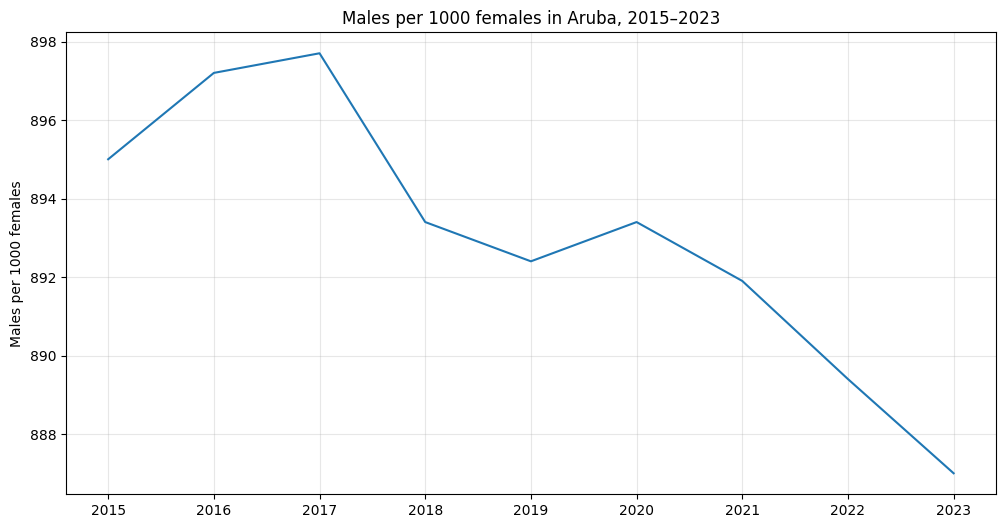

In [22]:
# Males per 1000 females in Aruba

plt.figure(figsize=(12, 6))

plt.plot(wide_df["year"], wide_df["males_per_1000_females"])
plt.title("Males per 1000 females in Aruba, 2015–2023")
plt.ylabel("Males per 1000 females")
plt.grid(alpha=0.3)

plt.savefig(FIGURES / "males_per_1000_females.png", dpi=300, bbox_inches="tight")

plt.show()

## 7. Key takeaways